In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
import os
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('../dataset/processed/clean_data.csv')
print(f"Full dataset: {df.shape}")

Full dataset: (180516, 45)


In [21]:
# Aggregate per customer — clustering is at customer level not order level
customer_df=df.groupby("Order Customer Id").agg(
    total_orders=("Order Id","count"),
    late_rate=("Late_delivery_risk","mean"),
    avg_delay_gap=("delay_gap",'mean'),
    avg_order_value=("Sales","mean"),
    avg_profit=("Order Profit Per Order",'mean'),
    unique_regegions=("Order Region",'nunique'),
    avg_discount=("Order Item Discount Rate",'mean')).reset_index()
print(f"Unique Customers : {customer_df.shape}")
print(customer_df.describe())

Unique Customers : (20649, 8)
       Order Customer Id  total_orders     late_rate  avg_delay_gap  \
count       20649.000000  20649.000000  20649.000000   20649.000000   
mean        10399.579205      8.742118      0.548731       0.568694   
std          5993.232139      8.375983      0.383953       1.152474   
min             1.000000      1.000000      0.000000      -2.000000   
25%          5208.000000      1.000000      0.185185       0.000000   
50%         10406.000000      7.000000      0.578947       0.666667   
75%         15594.000000     15.000000      1.000000       1.034483   
max         20757.000000     47.000000      1.000000       4.000000   

       avg_order_value    avg_profit  unique_regegions  avg_discount  
count     20649.000000  20649.000000      20649.000000  20649.000000  
mean        238.356716     26.178758          2.750932      0.101701  
std         215.415580    125.504337          1.923040      0.048244  
min          11.290000  -3442.500000          

## Clustering Task  Customer Risk Segmentation

Unlike classification and regression, clustering is unsupervised 
there is no target variable. We group customers based on their 
order behaviour and delivery history.

Aggregating to customer level: each row = one customer's profile
across all their orders. Features capture volume, delay history,
order value, and geographic spread.

In [22]:
# Drop the ID column before scaling
features = customer_df.drop(columns=['Order Customer Id'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Scaling done.")
print(f"Feature matrix shape: {scaled_features.shape}")

Scaling done.
Feature matrix shape: (20649, 7)


## Why Scaling is Essential for K-Means

K-Means uses Euclidean distance to assign cluster membership.
Without scaling, features with large ranges (like total_orders 
or avg_order_value) would dominate the distance calculation, 
drowning out smaller but equally important features like late_rate.

StandardScaler brings all features to mean=0 and std=1.

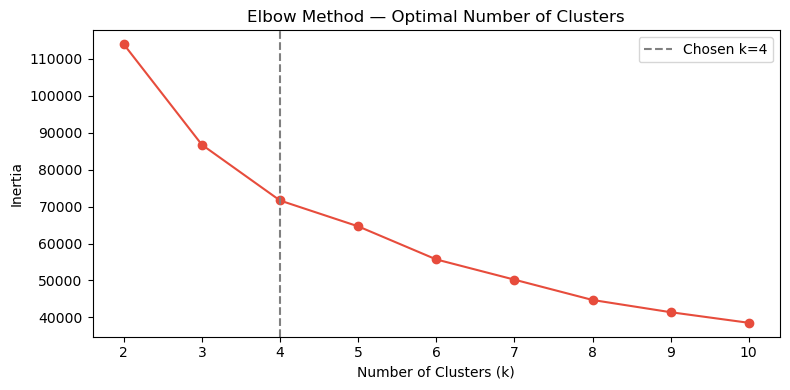

In [23]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='#e74c3c')
plt.axvline(x=4, color='gray', linestyle='--', label='Chosen k=4')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.legend()
plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Elbow Method

The elbow method plots inertia (sum of squared distances from each 
point to its cluster center) against k. The "elbow" where inertia 
stops dropping sharply indicates the optimal k.

We select k=4 as it gives a good balance between cluster granularity
and interpretability  four risk tiers map naturally to business 
categories: Low, Moderate, High, and Critical.

In [24]:
km=KMeans(n_clusters=4,random_state=42,n_init=10)
customer_df["Cluster"]=km.fit_predict(scaled_features)

print("Cluster Distribution")
print(customer_df['Cluster'].value_counts().sort_index())

Cluster Distribution
Cluster
0    6605
1    5320
2    8324
3     400
Name: count, dtype: int64


In [25]:
cluster_profile=customer_df.groupby("Cluster").agg(
    num_customers=('Order Customer Id','count'),
    avg_late_rate=('late_rate', 'mean'),
    avg_delay_gap=('avg_delay_gap', 'mean'),
    avg_total_orders=('total_orders', 'mean'),
    avg_order_value=('avg_order_value', 'mean')
).round(3)
print(cluster_profile)

         num_customers  avg_late_rate  avg_delay_gap  avg_total_orders  \
Cluster                                                                  
0                 6605          0.952          1.568             3.030   
1                 5320          0.054         -0.651             3.099   
2                 8324          0.547          0.561            17.253   
3                  400          0.505          0.448             1.000   

         avg_order_value  
Cluster                   
0                224.707  
1                222.075  
2                198.967  
3               1500.000  


## Cluster Profiles

Examine each cluster's average late_rate and avg_delay_gap to 
assign business labels.  
 The cluster with the highest late_rate  and delay_gap = Critical Risk. Lowest = Low Risk.

These profiles are what drive the business labels in the next cell.

In [26]:

tier_order = ["Critical Risk", "High Risk", "Moderate Risk", "Low Risk"]
cluster_rank = (
    customer_df.groupby("Cluster")["late_rate"]
    .mean()
    .sort_values(ascending=False)
    .index
)
risk_labels = {cluster_id: tier_order[rank] for rank, cluster_id in enumerate(cluster_rank)}
customer_df['Risk Tier'] = customer_df['Cluster'].map(risk_labels)
print(risk_labels)
print(customer_df['Risk Tier'].value_counts())

{0: 'Critical Risk', 2: 'High Risk', 3: 'Moderate Risk', 1: 'Low Risk'}
Risk Tier
High Risk        8324
Critical Risk    6605
Low Risk         5320
Moderate Risk     400
Name: count, dtype: int64


## Business Risk Tier Labels

Labels assigned based on each cluster's average late delivery rate:

- Critical Risk:  late_rate > 0.8  — needs immediate supplier review
- High Risk:      late_rate 0.6–0.8 — proactive communication needed
- Moderate Risk:  late_rate 0.4–0.6 — monitor closely
- Low Risk:       late_rate < 0.4  — performing within acceptable range

These tiers give operations teams an actionable customer watchlist.

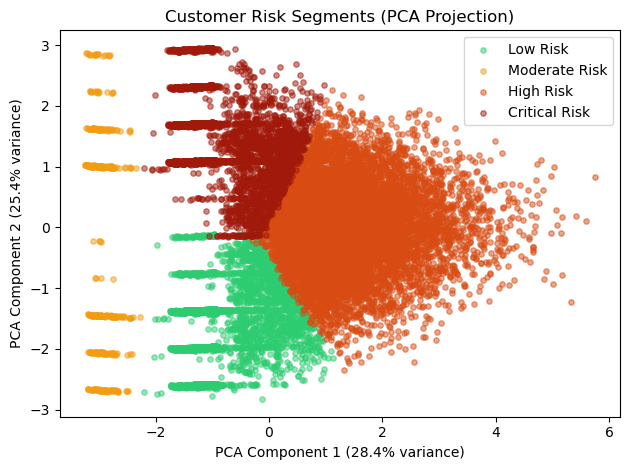

PCA explains 53.7% of total variance


In [27]:
pca=PCA(n_components=2,random_state=42)
pca_coords=pca.fit_transform(scaled_features)

customer_df['PCA1']=pca_coords[:,0]
customer_df['PCA2']=pca_coords[:,1]

colors = {
    'Low Risk': '#2ecc71',
    'Moderate Risk': '#f39c12',
    'High Risk': "#D84C14",
    'Critical Risk': "#a0190a"
}
plt.Figure(figsize=(10,6))
for tier,color in colors.items():
    mask=customer_df['Risk Tier']==tier
    plt.scatter(customer_df.loc[mask,'PCA1'],
        customer_df.loc[mask, 'PCA2'],
        c=color, label=tier, alpha=0.5, s=15    )

plt.title('Customer Risk Segments (PCA Projection)')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.savefig('reports/figures/cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance")
    

## PCA Cluster Visualisation

Since clustering happens in 7-dimensional space, we use PCA to 
project down to 2D for visualisation. Well-separated clusters 
in this plot confirm that K-Means found genuinely distinct groups.

Note: PCA is only for visualisation  the actual clustering was 
done on all 7 features.

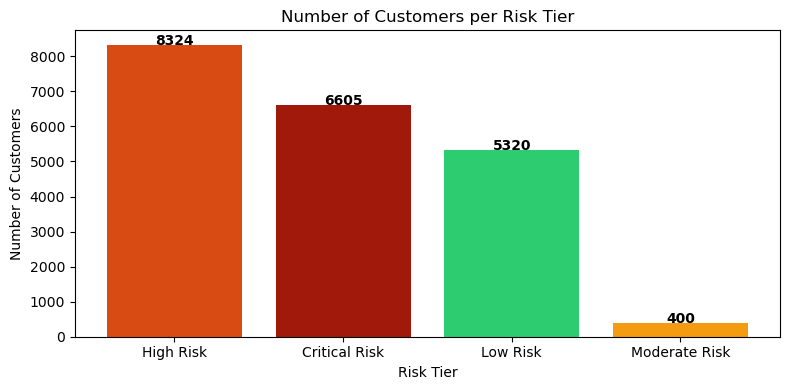

In [28]:
tier_counts = customer_df['Risk Tier'].value_counts()

plt.figure(figsize=(8, 4))
bars = plt.bar(tier_counts.index, tier_counts.values,
               color=["#D84C14","#a0190a",'#2ecc71','#f39c12'])
plt.title('Number of Customers per Risk Tier')
plt.xlabel('Risk Tier')
plt.ylabel('Number of Customers')

for bar, val in zip(bars, tier_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

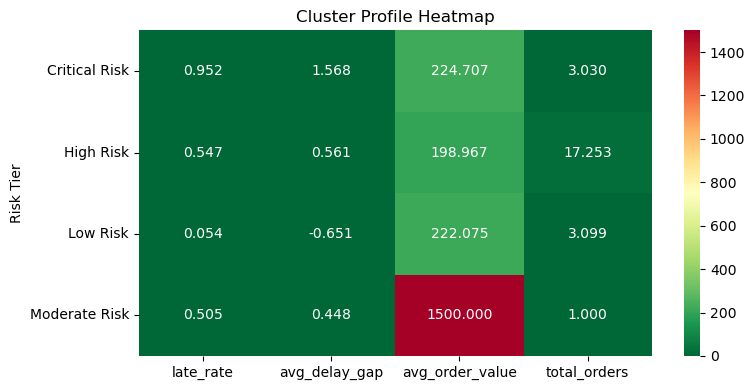

               late_rate  avg_delay_gap  avg_order_value  total_orders
Risk Tier                                                             
Critical Risk      0.952          1.568          224.707         3.030
High Risk          0.547          0.561          198.967        17.253
Low Risk           0.054         -0.651          222.075         3.099
Moderate Risk      0.505          0.448         1500.000         1.000


In [29]:
heatmap_data = customer_df.groupby('Risk Tier')[
    ['late_rate', 'avg_delay_gap', 'avg_order_value', 'total_orders']
].mean().round(3)

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn_r')
plt.title('Cluster Profile Heatmap')
plt.tight_layout()
plt.savefig('reports/figures/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(heatmap_data)

## Cluster Profile Heatmap

Confirms that risk tier labels are correctly assigned.
Critical Risk should show the highest late_rate and avg_delay_gap.
Low Risk should show the lowest across all delay metrics.

In [30]:
import joblib

os.makedirs('models', exist_ok=True)
os.makedirs('dataset/processed', exist_ok=True)

joblib.dump(km, 'models/kmeans_clustering.pkl')
joblib.dump(scaler, 'models/cluster_scaler.pkl')
customer_df.to_csv('dataset/processed/customer_segments.csv', index=False)

print("Model and segments saved.")
print(f"\nFinal customer segment summary:")
print(customer_df['Risk Tier'].value_counts())

Model and segments saved.

Final customer segment summary:
Risk Tier
High Risk        8324
Critical Risk    6605
Low Risk         5320
Moderate Risk     400
Name: count, dtype: int64
